# Blink Signals

|Previous Notebook|Current Notebook|Next Notebook|
|:-:|:-:|:-:|
|[separate.ipynb](./separate.ipynb)|<i>blink_signals.ipynb</i>|[alignment.ipynb](./alignment.ipynb)|

This is a preliminary exploration into HOW blinks are recognized in the **Muse S** system. The inspiration for this is that we've detected some unique signal patterns in the **TP9** and **TP10** channels of the Muse S. So let's actually explore what's going on here.

## Inspiration

Let's look at P1's data for now - specifically, the EEG signals for TP9 and TP10 during the calibration phases.

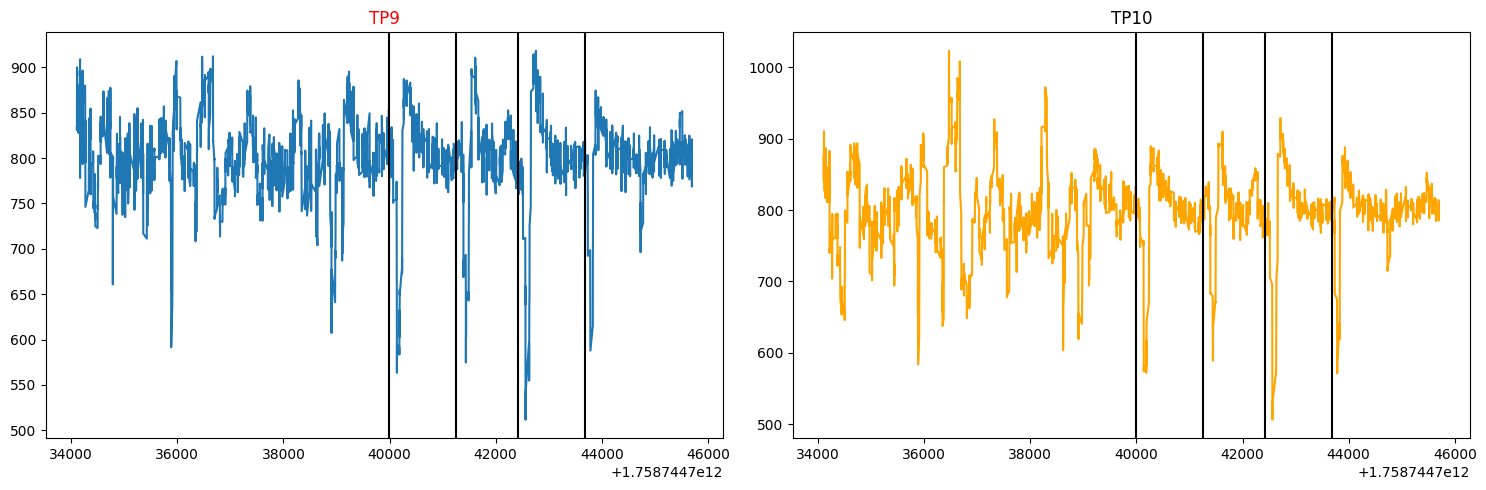

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the EEG data
df = pd.read_csv('./data/P1/trials/1/calibration/eeg_raw.csv').drop(columns=['Unnamed: 0'])
x = df['unix_ms'].to_list()
y1 = df['TP9'].to_list()
y2 = df['TP10'].to_list()

# Read calibration data
cdf = pd.read_csv('./data/P1/trials/1/calibration/calibration.csv').drop(columns=['Unnamed: 0'])
cdf = cdf[cdf['event']=='Overlap']

fig, axes = plt.subplots(1,2,figsize=(15,5))
axes[0].plot(x, y1)
axes[0].set_title('TP9', c='red')
axes[1].plot(x, y2, c='orange')
axes[1].set_title('TP10')

for _, row in cdf.iterrows():
    axes[0].axvline(x=row['unix_ms'], c='black')
    axes[1].axvline(x=row['unix_ms'], c='black')

plt.tight_layout()
plt.show()

Note that there's a very distinct pattern at each overlap onset ("Overlap" = when a red circle overlaps a gray circle in the simulation, prompting a blink from the user). There's a distinct valley, then a peak, then a return to normal value. What causes this pattern to generate?

## Steps to Experiment

Let's explore the following:

1. What does the EEG signal look like when the user closes their eyes but doesn't open them again (i.e. keep them closed)?
2. What does the EEG signal look like after having eyes closed, opening them again?
3. What does the EEG signal look like during a normal blink?
4. What does the EEG signal look like during a slow blink?

Let's graph the data, which is stored inside of `./data/blink_samples/sample_1.csv`:

In [10]:
import importlib
from components import eeg_handling
importlib.reload(eeg_handling)

eeg, blinks = eeg_handling.read('./data/blink_samples/sample_1.csv')
raw, processed = eeg_handling.separate(eeg)
display(raw.head(10))

/Users/ryankim/Documents/CodeProjects/eeg_blink_calibration/src/components/eeg_handling.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df.rename(columns=raw_colnames, inplace=True)


,unix_sec,unix_ms,rel_sec,rel_ms,TP9,TP10,AF7,AF8
1,1.761155e+09,1761154544432,0.044,44,794.98170,792.16120,784.10254,801.42860
2,1.761155e+09,1761154544433,0.045,45,802.23444,788.53480,853.80950,805.05493
3,1.761155e+09,1761154544433,0.045,45,808.27840,791.75824,824.79850,806.66670
4,1.761155e+09,1761154544434,0.046,46,803.84610,790.95240,776.84980,806.66670
5,1.761155e+09,1761154544434,0.046,46,804.24910,787.72894,787.32600,807.06960
6,1.761155e+09,1761154544434,0.046,46,809.08420,790.95240,846.15390,809.08420
7,1.761155e+09,1761154544436,0.048,48,803.84610,790.95240,846.95970,810.29300
8,1.761155e+09,1761154544436,0.048,48,799.81683,789.74360,780.47620,805.86080
9,1.761155e+09,1761154544437,0.049,49,800.21980,788.53480,755.89746,802.23444
10,1.761155e+09,1761154544437,0.049,49,796.59340,786.52014,791.75824,796.99634


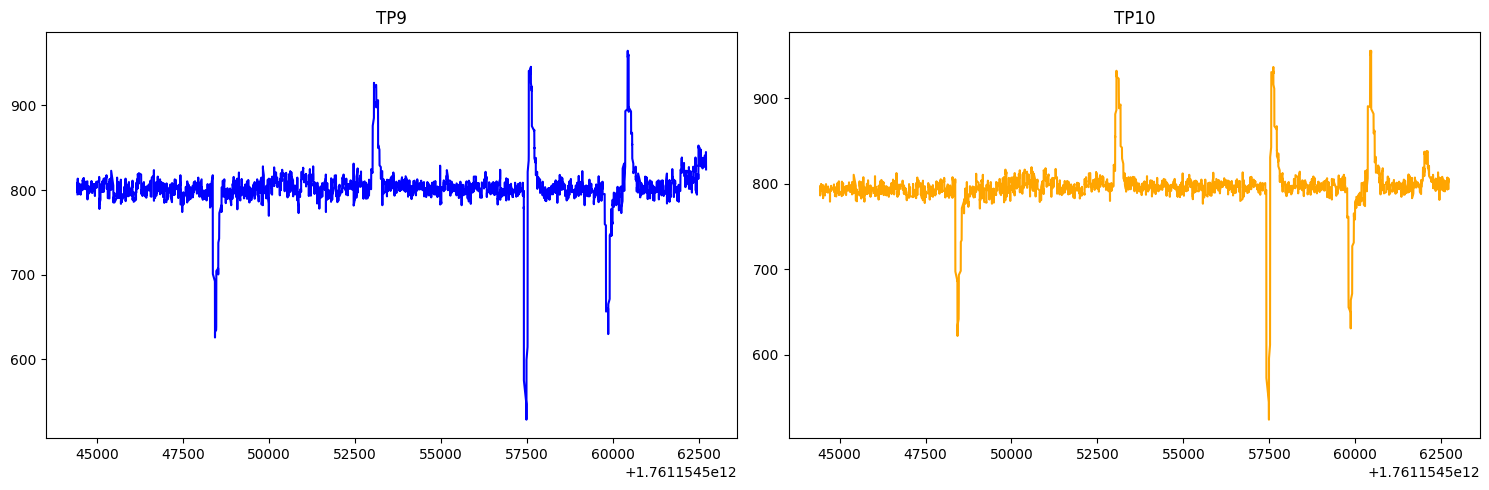

In [12]:
x = raw['unix_ms'].to_list()
y1 = raw['TP9'].to_list()
y2 = raw['TP10'].to_list()

fig, axes = plt.subplots(1,2,figsize=(15,5))
axes[0].plot(x, y1, c='blue')
axes[0].set_title('TP9')
axes[1].plot(x, y2, c='orange')
axes[1].set_title('TP10')

plt.tight_layout()
plt.show()

Things to note:

1. The first major VALLEY corresponds to the eye in a closing motion, and keeping them closed. It looks like, upon the blink being completed, the signal returns to its original median signal value even when the eye remains closed.
2. The first major PEAK corresponds to the eye opening after keeping it closed.
3. The first major valley => peak corresponds to a normal blink. It appears that the speed (or strength?) of the blink corresponds to the strength of the valley and only to the peak a little bit.
4. The second major valley => peak corresponds to a slower blink.
5. When the eyes are closed, upon closing, there's a little bit of a delay where the signal power in both TP9 and TP10 remain slightly _below_ the midline, but this only lasts for a few milliseconds. This is evident in the first major valley as well as blink.

There are some notable things to consider, from this pattern:

- **The action of closing the eye produces a valley**
- **The action of opening the eye produces a peak**
- **EEG signals, without interference, remain normalized to some base value**. In this sample data, TP9 and TP10 have a median normalized value of 800, approximately.
- It can be _intuitied_ that for a blink detection system, we can safely identify the moment on the blink as when:
    1. the valley passes the midline towards the peak, and/or,
    2. The short moment when the signal power is slighly below the midline.

## Smoothed Data?

Let's smooth out the data and see if we get improved results. To achieve the smoothing, I'm using the popular [Savitzky-Golay Filter](https://en.wikipedia.org/wiki/Savitzky%E2%80%93Golay_filter), implemented via [scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.savgol_filter.html). The filter is described further via [this video](https://www.youtube.com/watch?v=cY-OBfCnOxU). Let's create an **interactive** visualization that let's us adjust the filter params.

In [ ]:
from scipy.signal import savgol_filter
from ipywidgets import interact, FloatSlider, IntSlider

x = raw['unix_ms'].to_list()
y1 = raw['TP9'].to_list()
y2 = raw['TP10'].to_list()

def update_plot(wl=100, poly=3):

    # Initialize our plot
    fig, axes = plt.subplots(1,2,figsize=(15,5))
    axes[0].set_title('TP9')
    axes[1].set_title('TP10')

    # original data
    axes[0].plot(x, y1, c='blue', alpha=0.25)
    axes[1].plot(x, y2, c='orange', alpha=0.25)

    # Smooth the data
    y1_smoothed = savgol_filter(y1, window_length=wl, polyorder=poly, mode='nearest')
    y2_smoothed = savgol_filter(y2, window_length=wl, polyorder=poly, mode='nearest')
    axes[0].plot(x, y1_smoothed, c='blue')
    axes[1].plot(x, y2_smoothed, c='orange')
    
    # Plot
    plt.tight_layout()
    plt.show()

# Inputs
interact(
    update_plot,
    wl = FloatSlider(value=100, min=10, max=200, step=0.1, description='Window Length'),
    poly = IntSlider(value=4, min=1, max=5, step=1, description='Poly Order')
)

interactive(children=(FloatSlider(value=100.0, description='Window Length', max=200.0, min=10.0), IntSlider(va…

<function __main__.update_plot(wl=100, poly=3)>

The signal appears to look much better when the data is smoothed. Not completely clean, but it's better than the raw signal. The parameters here are a window length of `100` and a poly order of `3`.

## Half-Closed Eyes

What does the signal look like if you attempt to keep eyes half-closed? This data comes from `data/blink_samples/sample_2.csv`. The actions corresponding to this are:

1. Close eyes, keep closed
2. Open eyes from closed
3. Close eyes halfway, keep halfway closed
4. Open eyes from closed
5. Normal blink
6. Slow blink

In [17]:
eeg2, _ = eeg_handling.read('./data/blink_samples/sample_2.csv')
raw2, processed2 = eeg_handling.separate(eeg2)

x = raw2['unix_ms'].to_list()
y1 = raw2['TP9'].to_list()
y2 = raw2['TP10'].to_list()

def update_plot(wl=100, poly=3):

    # Initialize our plot
    fig, axes = plt.subplots(1,2,figsize=(15,5))
    axes[0].set_title('TP9')
    axes[1].set_title('TP10')

    # original data
    axes[0].plot(x, y1, c='blue', alpha=0.25)
    axes[1].plot(x, y2, c='orange', alpha=0.25)

    # Smooth the data
    y1_smoothed = savgol_filter(y1, window_length=wl, polyorder=poly, mode='nearest')
    y2_smoothed = savgol_filter(y2, window_length=wl, polyorder=poly, mode='nearest')
    axes[0].plot(x, y1_smoothed, c='blue')
    axes[1].plot(x, y2_smoothed, c='orange')
    
    # Plot
    plt.tight_layout()
    plt.show()

# Inputs
interact(
    update_plot,
    wl = FloatSlider(value=100, min=10, max=200, step=0.1, description='Window Length'),
    poly = IntSlider(value=4, min=1, max=5, step=1, description='Poly Order')
)

/Users/ryankim/Documents/CodeProjects/eeg_blink_calibration/src/components/eeg_handling.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df.rename(columns=raw_colnames, inplace=True)


interactive(children=(FloatSlider(value=100.0, description='Window Length', max=200.0, min=10.0), IntSlider(va…

<function __main__.update_plot(wl=100, poly=3)>

So this is interesting:

1. The eyes closed and the eyes half-closed produce similar patterns, but the strength of the valley and peaks are smaller for the half-closed condition.
2. The data looks wonky with the slow blink, so let's ignore that.

This gives us some idea of what's happening: when the blink occurs, the strength of the signal noise generated is proportional to the amount of movement. Half-blinks will disrupt the EEG no more than halfway than a full eye-closed motion, for example. The inherent pattern still holds, nonetheless.

## What does the literature say?

According to [this paper (1985)](https://doi.org/10.1152/jn.1985.54.1.11), eye movements result in a downward, nasalward movement of the eyes during a blink gesture. These movements have shorter durations than the eyelid movement, and the movement of the eyes differ from that of the eyelids. Prolonged eye closure results in eye movements that drift upward or downward involuntarily, with a variable horizontal component. It is likely that transient eye movements are likely due to active muscle contractions rather than passive mechanisms of the eyelid. 

There is a mention of ["Bell's Phenomenon"](https://en.wikipedia.org/wiki/Bell%27s_phenomenon), which describes eye movements when an attempt to close the eyes are made. The previous paper mentions that Bell's Phenomenon has not been observed during short blinks. But what is Bell's Phenomenon? Bell's Phenomenon is defined as the following (simplified on Wikipedia, originally sourced by [this paper (2001)](https://pmc.ncbi.nlm.nih.gov/articles/PMC1121451/)):

> "[An] upward and outward movement of the eye, when an attempt is made to close the eyes. The upward movement of the eye is present in the majority of the population, and is a defensive mechanism."

[This video (2022)](https://www.youtube.com/watch?v=wxmBSyWD4mU&t=82s) elaborates that Bell's Phenomenon is a **defensive reflex** that occurs during **forced** eye closure (i.e. when something is about to hit your face and you force-close your eyes to protect them). It is not immediately clear from this video if Bell's Phenomenon is something that occurs **normally** during blinks.

[This report (2022)](https://isip.piconepress.com/conferences/ieee_spmb/2022/papers/l01_03.pdf) directly from the company that made Muse (supposedly) describes their algorithm for detecting blinks using single electrodes. They explain the same thing we've observed - that there's an aggressive valley accompanied by a smaller peak that's associated with a blink gesture. They use an algorithm that's actually kind of effective and makes very little assumptions about the signal behavior prior. They define the blink behavior as such:

> Eye-blinks are noticeable in EEG signal recordings, as seen in Figure 1, and can be described with respect to
the measured baseline voltage. The eye-blink starts with a steep drop in the measured voltage, representing the
closing of the eyelid. It is then followed by a steep rise that crosses the baseline and reaches higher voltages,
representing the opening of the eyelid. Finally, it is followed by a return to the measured baseline.

### Inferences to our work

I think at this point, it's safe to bet about the following:

- In the EEG signal, when the eye is closed, this corresponds to the largest detected valley. The signal will always return to the baseline (which can be measured based on the mean of the signal).
- If we want any blink alignment with other systems, then we need to time it in comparison to this minimum valley.

###

## What's Next?

|Previous Notebook|Current Notebook|Next Notebook|
|:-:|:-:|:-:|
|[separate.ipynb](./separate.ipynb)|<i>blink_signals.ipynb</i>|[alignment.ipynb](./alignment.ipynb)|